In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Proyecto_PINN_HRF")

SUBJECT_ID = "100206"

RAW_RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / SUBJECT_ID
)

SYNTHETIC_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
)

SYNTHETIC_CLEAN_DIR = (
    SYNTHETIC_DATA_DIR
    / "clean"
)

SYNTHETIC_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
)

for directory in [
    SYNTHETIC_DATA_DIR,
    SYNTHETIC_CLEAN_DIR,
    SYNTHETIC_RESULTS_DIR,
    FIGURES_DIR,
    CONFIG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Directorios creados correctamente.")

Directorios creados correctamente.


In [4]:
metadata_lr_path = (
    PROCESSED_DIR
    / "motor_lr_metadata.json"
)

metadata_rl_path = (
    PROCESSED_DIR
    / "motor_rl_metadata.json"
)

with open(metadata_lr_path, encoding="utf-8") as file:
    metadata_lr = json.load(file)

with open(metadata_rl_path, encoding="utf-8") as file:
    metadata_rl = json.load(file)

tr_lr = float(metadata_lr["tr_s"])
tr_rl = float(metadata_rl["tr_s"])

n_volumes_lr = int(metadata_lr["n_volumes"])
n_volumes_rl = int(metadata_rl["n_volumes"])

if not np.isclose(tr_lr, tr_rl):
    raise ValueError(
        f"Los TR son distintos: LR={tr_lr}, RL={tr_rl}"
    )

if n_volumes_lr != n_volumes_rl:
    raise ValueError(
        "Las corridas presentan distintos números de volúmenes."
    )

TR = tr_lr
N_VOLUMES = n_volumes_lr

FRAME_TIMES = (
    np.arange(N_VOLUMES, dtype=float)
    * TR
)

print(f"TR: {TR:.2f} s")
print(f"Volúmenes: {N_VOLUMES}")
print(f"Tiempo final: {FRAME_TIMES[-1]:.2f} s")

TR: 0.72 s
Volúmenes: 284
Tiempo final: 203.76 s


In [5]:
def cargar_evento_hcp(
    events_dir: Path,
    condition: str,
) -> pd.DataFrame:
    """
    Lee un archivo EV del HCP.

    Columnas:
    - onset_s
    - duration_s
    - amplitude
    """
    event_path = events_dir / f"{condition}.txt"

    if not event_path.exists():
        raise FileNotFoundError(
            f"No se encontró: {event_path}"
        )

    values = np.loadtxt(
        event_path,
        ndmin=2,
    )

    if values.shape[1] < 3:
        raise ValueError(
            f"{event_path.name} no contiene tres columnas."
        )

    events = pd.DataFrame(
        {
            "onset_s": values[:, 0],
            "duration_s": values[:, 1],
            "amplitude": values[:, 2],
        }
    )

    events["condition"] = condition
    events["end_s"] = (
        events["onset_s"]
        + events["duration_s"]
    )

    return events

In [6]:
scenarios = {
    "motor_lr_m1_left": {
        "run": "MOTOR_LR",
        "roi": "M1_left",
        "condition": "rh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
            / "EVs"
        ),
    },
    "motor_lr_m1_right": {
        "run": "MOTOR_LR",
        "roi": "M1_right",
        "condition": "lh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
            / "EVs"
        ),
    },
    "motor_rl_m1_left": {
        "run": "MOTOR_RL",
        "roi": "M1_left",
        "condition": "rh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
            / "EVs"
        ),
    },
    "motor_rl_m1_right": {
        "run": "MOTOR_RL",
        "roi": "M1_right",
        "condition": "lh",
        "events_dir": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
            / "EVs"
        ),
    },
}

for scenario_name, scenario in scenarios.items():
    scenario["events"] = cargar_evento_hcp(
        scenario["events_dir"],
        scenario["condition"],
    )

    print(
        scenario_name,
        "—",
        len(scenario["events"]),
        "bloques"
    )

    display(scenario["events"])

motor_lr_m1_left — 2 bloques


,onset_s,duration_s,amplitude,condition,end_s
0,11.009,12.0,1.0,rh,23.009
1,131.892,12.0,1.0,rh,143.892


motor_lr_m1_right — 2 bloques


,onset_s,duration_s,amplitude,condition,end_s
0,71.517,12.0,1.0,lh,83.517
1,162.013,12.0,1.0,lh,174.013


motor_rl_m1_left — 2 bloques


,onset_s,duration_s,amplitude,condition,end_s
0,86.498,12.0,1.0,rh,98.498
1,162.000,12.0,1.0,rh,174.000


motor_rl_m1_right — 2 bloques


,onset_s,duration_s,amplitude,condition,end_s
0,10.996,12.0,1.0,lh,22.996
1,116.619,12.0,1.0,lh,128.619


In [7]:
GROUND_TRUTH_PARAMETERS = {
    # Eficacia de la entrada neuronal
    "epsilon": 0.15,

    # Decaimiento de la señal vasodilatadora [s^-1]
    "kappa_s": 0.65,

    # Retroalimentación autorreguladora del flujo [s^-1]
    "kappa_f": 0.41,

    # Tiempo de tránsito venoso medio [s]
    "tau": 0.98,

    # Exponente de Grubb
    "alpha": 0.32,

    # Fracción basal de extracción de oxígeno
    "E0": 0.34,

    # Fracción basal de volumen sanguíneo
    "V0": 0.02,

    # Coeficientes de observación BOLD
    "k1": 7.0 * 0.34,
    "k2": 2.0,
    "k3": 2.0 * 0.34 - 0.2,
}

display(
    pd.DataFrame(
        {
            "parameter": GROUND_TRUTH_PARAMETERS.keys(),
            "value": GROUND_TRUTH_PARAMETERS.values(),
        }
    )
)

,parameter,value
0,epsilon,0.15
1,kappa_s,0.65
2,kappa_f,0.41
3,tau,0.98
4,alpha,0.32
5,E0,0.34
6,V0,0.02
7,k1,2.38
8,k2,2.00
9,k3,0.48


In [8]:
ground_truth_config_path = (
    CONFIG_DIR
    / "synthetic_ground_truth.json"
)

with open(
    ground_truth_config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        GROUND_TRUTH_PARAMETERS,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Configuración guardada en:")
print(ground_truth_config_path)

Configuración guardada en:
/content/drive/MyDrive/Proyecto_PINN_HRF/configs/synthetic_ground_truth.json


In [9]:
def construir_estimulo(
    events: pd.DataFrame,
):
    """
    Construye una función continua por bloques a partir
    de los eventos del HCP.
    """
    onsets = (
        events["onset_s"]
        .to_numpy(dtype=float)
    )

    durations = (
        events["duration_s"]
        .to_numpy(dtype=float)
    )

    amplitudes = (
        events["amplitude"]
        .to_numpy(dtype=float)
    )

    ends = onsets + durations

    def stimulus(time_s: float) -> float:
        active = (
            (time_s >= onsets)
            & (time_s < ends)
        )

        return float(
            np.sum(amplitudes[active])
        )

    return stimulus

In [10]:
def balloon_windkessel_rhs(
    time_s: float,
    state: np.ndarray,
    stimulus,
    parameters: dict,
) -> list[float]:
    """
    Sistema Balloon-Windkessel.

    Estados:
    s: señal vasodilatadora
    f: flujo sanguíneo normalizado
    v: volumen venoso normalizado
    q: desoxihemoglobina normalizada
    """
    s, f, v, q = state

    epsilon = parameters["epsilon"]
    kappa_s = parameters["kappa_s"]
    kappa_f = parameters["kappa_f"]
    tau = parameters["tau"]
    alpha = parameters["alpha"]
    E0 = parameters["E0"]

    # Protección únicamente frente a errores numéricos
    f_safe = max(float(f), 1e-8)
    v_safe = max(float(v), 1e-8)

    neural_input = stimulus(time_s)

    oxygen_extraction = (
        1.0
        - (1.0 - E0) ** (1.0 / f_safe)
    )

    ds_dt = (
        epsilon * neural_input
        - kappa_s * s
        - kappa_f * (f - 1.0)
    )

    df_dt = s

    dv_dt = (
        f
        - v_safe ** (1.0 / alpha)
    ) / tau

    dq_dt = (
        (
            f
            * oxygen_extraction
            / E0
        )
        - (
            v_safe ** (1.0 / alpha)
            * q
            / v_safe
        )
    ) / tau

    return [
        ds_dt,
        df_dt,
        dv_dt,
        dq_dt,
    ]

In [11]:
def calcular_bold(
    v: np.ndarray,
    q: np.ndarray,
    parameters: dict,
) -> np.ndarray:
    """
    Calcula el cambio BOLD fraccional.
    """
    V0 = parameters["V0"]
    k1 = parameters["k1"]
    k2 = parameters["k2"]
    k3 = parameters["k3"]

    v_safe = np.maximum(v, 1e-8)

    bold = V0 * (
        k1 * (1.0 - q)
        + k2 * (1.0 - q / v_safe)
        + k3 * (1.0 - v_safe)
    )

    return bold

In [12]:
def simular_balloon_windkessel(
    frame_times: np.ndarray,
    events: pd.DataFrame,
    parameters: dict,
    max_step_s: float = 0.05,
) -> pd.DataFrame:
    """
    Simula el modelo Balloon-Windkessel sobre los tiempos
    de adquisición del fMRI.
    """
    frame_times = np.asarray(
        frame_times,
        dtype=float,
    )

    if frame_times.ndim != 1:
        raise ValueError(
            "frame_times debe ser un vector unidimensional."
        )

    if not np.all(np.diff(frame_times) > 0):
        raise ValueError(
            "frame_times debe ser estrictamente creciente."
        )

    stimulus = construir_estimulo(events)

    initial_state = np.array(
        [0.0, 1.0, 1.0, 1.0],
        dtype=float,
    )

    solution = solve_ivp(
        fun=lambda time_s, state: balloon_windkessel_rhs(
            time_s,
            state,
            stimulus,
            parameters,
        ),
        t_span=(
            float(frame_times[0]),
            float(frame_times[-1]),
        ),
        y0=initial_state,
        t_eval=frame_times,
        method="RK45",
        max_step=max_step_s,
        rtol=1e-8,
        atol=1e-10,
    )

    if not solution.success:
        raise RuntimeError(
            f"La integración falló: {solution.message}"
        )

    s, f, v, q = solution.y

    bold_fraction = calcular_bold(
        v,
        q,
        parameters,
    )

    stimulus_values = np.array(
        [
            stimulus(time_s)
            for time_s in frame_times
        ],
        dtype=float,
    )

    results = pd.DataFrame(
        {
            "time_s": frame_times,
            "stimulus": stimulus_values,
            "s": s,
            "f": f,
            "v": v,
            "q": q,
            "bold_fraction": bold_fraction,
            "bold_percent": 100.0 * bold_fraction,
        }
    )

    return results

In [13]:
clean_results = {}
summary_rows = []

for scenario_name, scenario in scenarios.items():

    result = simular_balloon_windkessel(
        frame_times=FRAME_TIMES,
        events=scenario["events"],
        parameters=GROUND_TRUTH_PARAMETERS,
    )

    clean_results[scenario_name] = result

    output_path = (
        SYNTHETIC_CLEAN_DIR
        / f"{scenario_name}_clean.csv"
    )

    result.to_csv(
        output_path,
        index=False,
    )

    summary_rows.append(
        {
            "scenario": scenario_name,
            "run": scenario["run"],
            "roi": scenario["roi"],
            "condition": scenario["condition"],
            "n_timepoints": len(result),
            "bold_min_percent": float(
                result["bold_percent"].min()
            ),
            "bold_max_percent": float(
                result["bold_percent"].max()
            ),
            "bold_std_percent": float(
                result["bold_percent"].std(ddof=0)
            ),
            "f_min": float(result["f"].min()),
            "f_max": float(result["f"].max()),
            "v_min": float(result["v"].min()),
            "v_max": float(result["v"].max()),
            "q_min": float(result["q"].min()),
            "q_max": float(result["q"].max()),
        }
    )

    print(
        f"{scenario_name}: "
        f"BOLD máximo = "
        f"{result['bold_percent'].max():.3f} %"
    )

motor_lr_m1_left: BOLD máximo = 1.668 %
motor_lr_m1_right: BOLD máximo = 1.669 %
motor_rl_m1_left: BOLD máximo = 1.667 %
motor_rl_m1_right: BOLD máximo = 1.668 %


In [14]:
clean_summary = pd.DataFrame(summary_rows)

clean_summary_path = (
    SYNTHETIC_RESULTS_DIR
    / "clean_simulation_summary.csv"
)

clean_summary.to_csv(
    clean_summary_path,
    index=False,
)

display(clean_summary)

,scenario,run,roi,condition,n_timepoints,bold_min_percent,bold_max_percent,bold_std_percent,f_min,f_max,v_min,v_max,q_min,q_max
0,motor_lr_m1_left,MOTOR_LR,M1_left,rh,284,-0.230367,1.668361,0.479048,0.943916,1.423288,0.982271,1.119128,0.836738,1.021281
1,motor_lr_m1_right,MOTOR_LR,M1_right,lh,284,-0.230456,1.668519,0.479048,0.943872,1.423309,0.982146,1.119249,0.836742,1.021313
2,motor_rl_m1_left,MOTOR_RL,M1_left,rh,284,-0.229321,1.667293,0.479049,0.944256,1.423329,0.982139,1.119266,0.836769,1.021309
3,motor_rl_m1_right,MOTOR_RL,M1_right,lh,284,-0.230301,1.668272,0.479049,0.943942,1.423254,0.982130,1.119291,0.836737,1.021300


In [15]:
def verificar_simulacion(
    result: pd.DataFrame,
    scenario_name: str,
) -> dict:
    """
    Comprueba condiciones básicas de estabilidad.
    """
    required_columns = [
        "s",
        "f",
        "v",
        "q",
        "bold_fraction",
    ]

    contains_nan = (
        result[required_columns]
        .isna()
        .any()
        .any()
    )

    finite_values = np.isfinite(
        result[required_columns]
        .to_numpy()
    ).all()

    positive_f = bool(
        (result["f"] > 0).all()
    )

    positive_v = bool(
        (result["v"] > 0).all()
    )

    positive_q = bool(
        (result["q"] > 0).all()
    )

    validation = {
        "scenario": scenario_name,
        "contains_nan": contains_nan,
        "all_values_finite": finite_values,
        "f_positive": positive_f,
        "v_positive": positive_v,
        "q_positive": positive_q,
    }

    return validation

In [16]:
validation_rows = []

for scenario_name, result in clean_results.items():
    validation_rows.append(
        verificar_simulacion(
            result,
            scenario_name,
        )
    )

validation_summary = pd.DataFrame(
    validation_rows
)

display(validation_summary)

,scenario,contains_nan,all_values_finite,f_positive,v_positive,q_positive
0,motor_lr_m1_left,False,True,True,True,True
1,motor_lr_m1_right,False,True,True,True,True
2,motor_rl_m1_left,False,True,True,True,True
3,motor_rl_m1_right,False,True,True,True,True


In [17]:
def graficar_simulacion_limpia(
    result: pd.DataFrame,
    scenario_name: str,
) -> None:
    """
    Grafica estímulo, señal BOLD y estados hemodinámicos.
    """
    figure, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
        sharex=True,
    )

    axes[0].plot(
        result["time_s"],
        result["stimulus"],
        linewidth=1.5,
    )

    axes[0].set_ylabel("Estímulo")
    axes[0].set_title(
        f"Simulación Balloon-Windkessel — {scenario_name}"
    )
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        result["time_s"],
        result["bold_percent"],
        linewidth=2.0,
    )

    axes[1].axhline(
        0.0,
        linewidth=0.8,
    )

    axes[1].set_ylabel("Cambio BOLD [%]")
    axes[1].grid(alpha=0.25)

    axes[2].plot(
        result["time_s"],
        result["f"],
        label="Flujo f",
    )

    axes[2].plot(
        result["time_s"],
        result["v"],
        label="Volumen v",
    )

    axes[2].plot(
        result["time_s"],
        result["q"],
        label="Desoxihemoglobina q",
    )

    axes[2].set_xlabel("Tiempo [s]")
    axes[2].set_ylabel("Estado normalizado")
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / f"synthetic_clean_{scenario_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Figura guardada:", output_path)

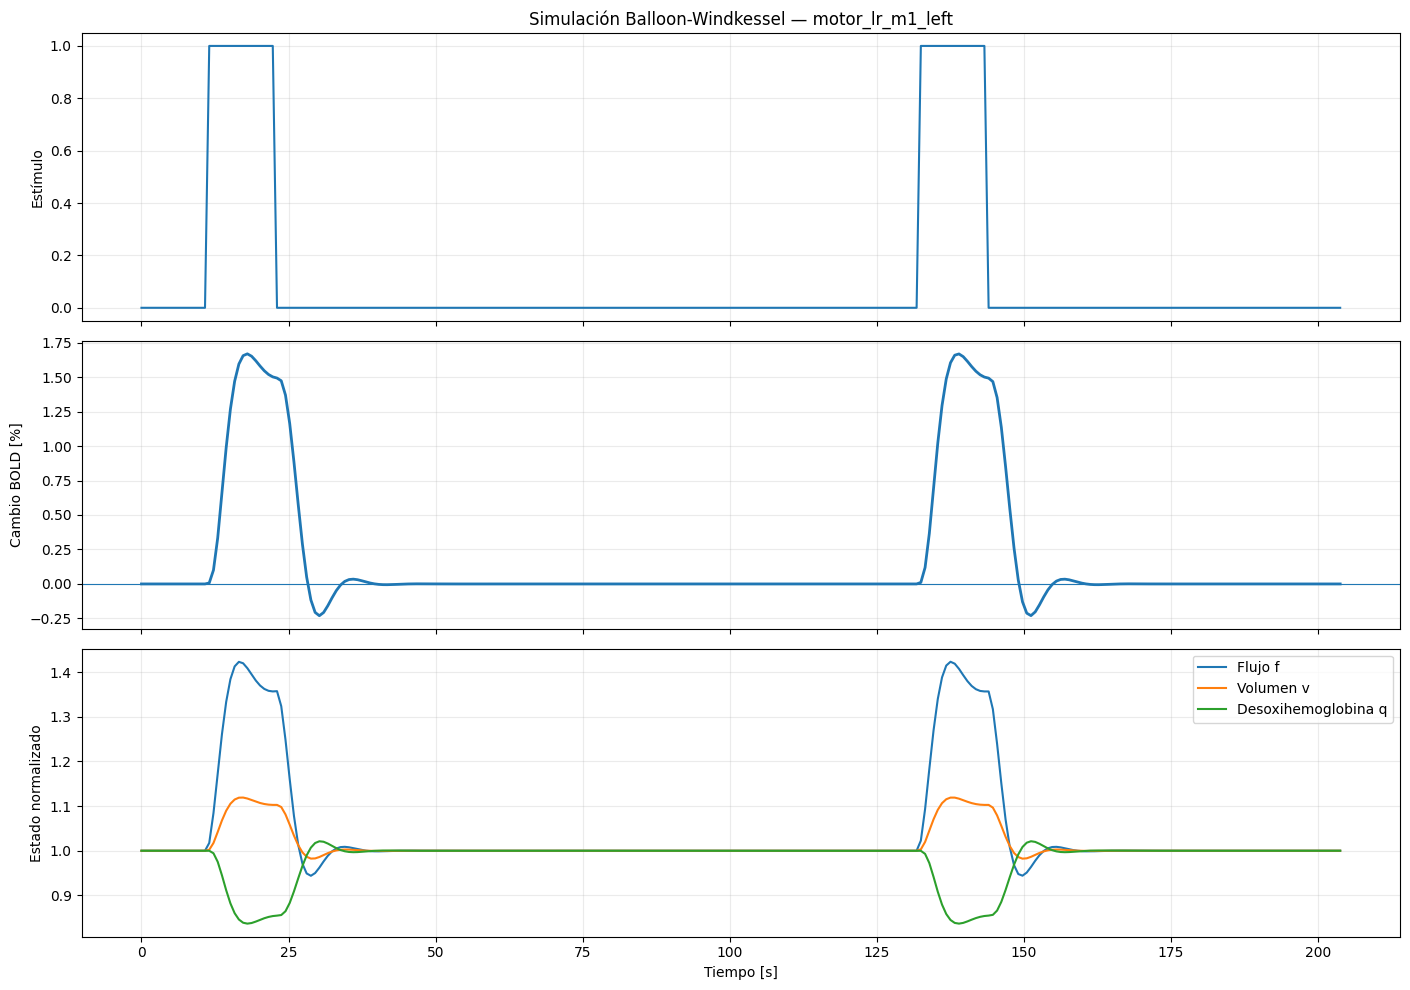

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_clean_motor_lr_m1_left.png


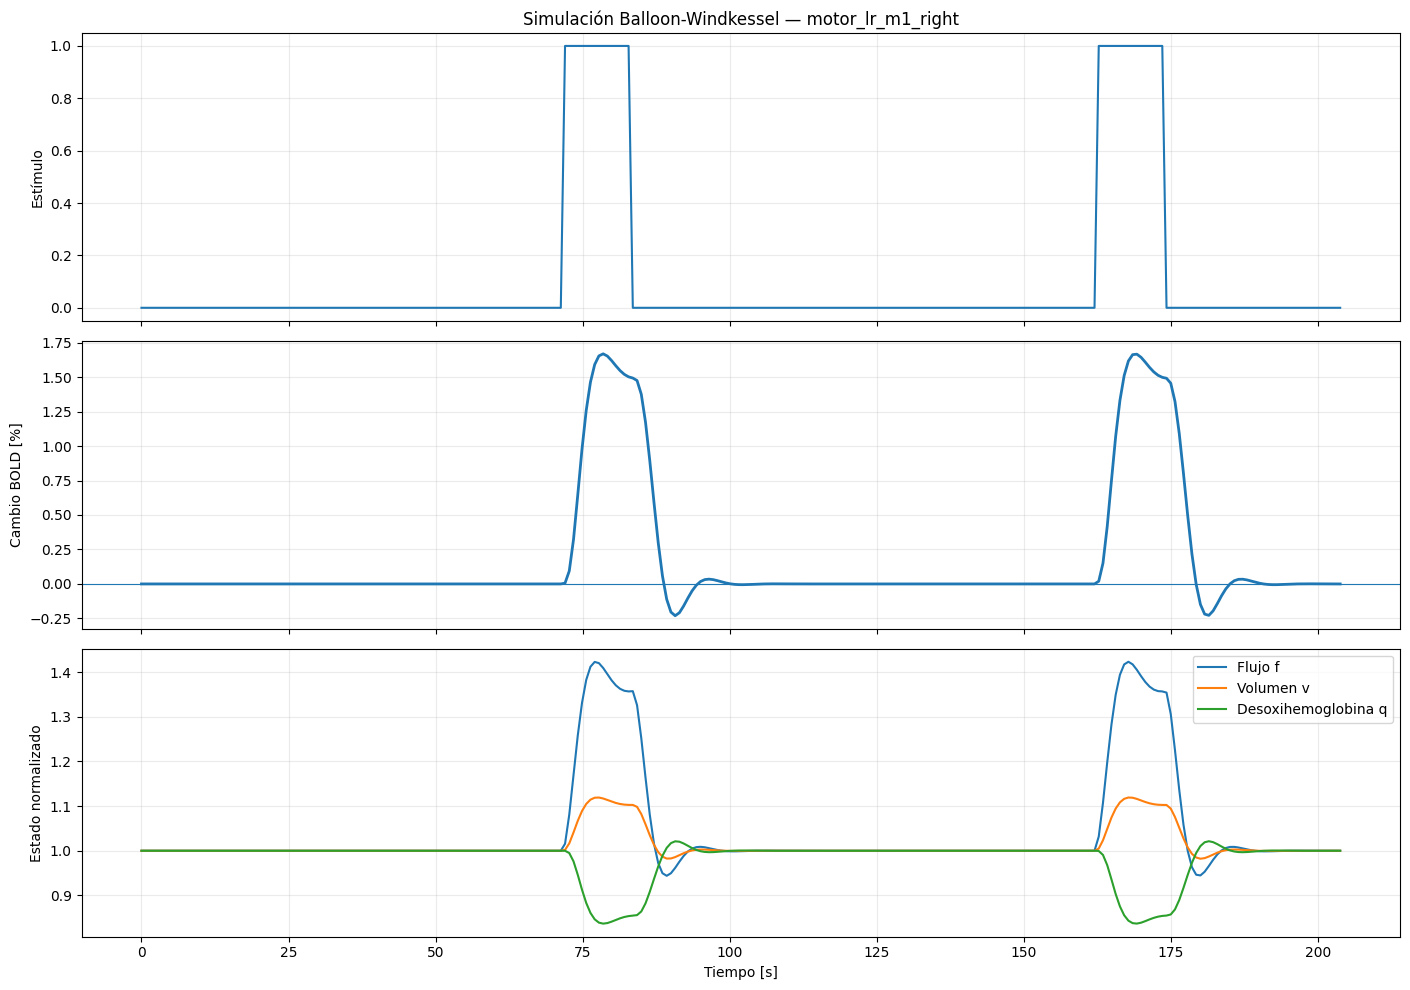

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_clean_motor_lr_m1_right.png


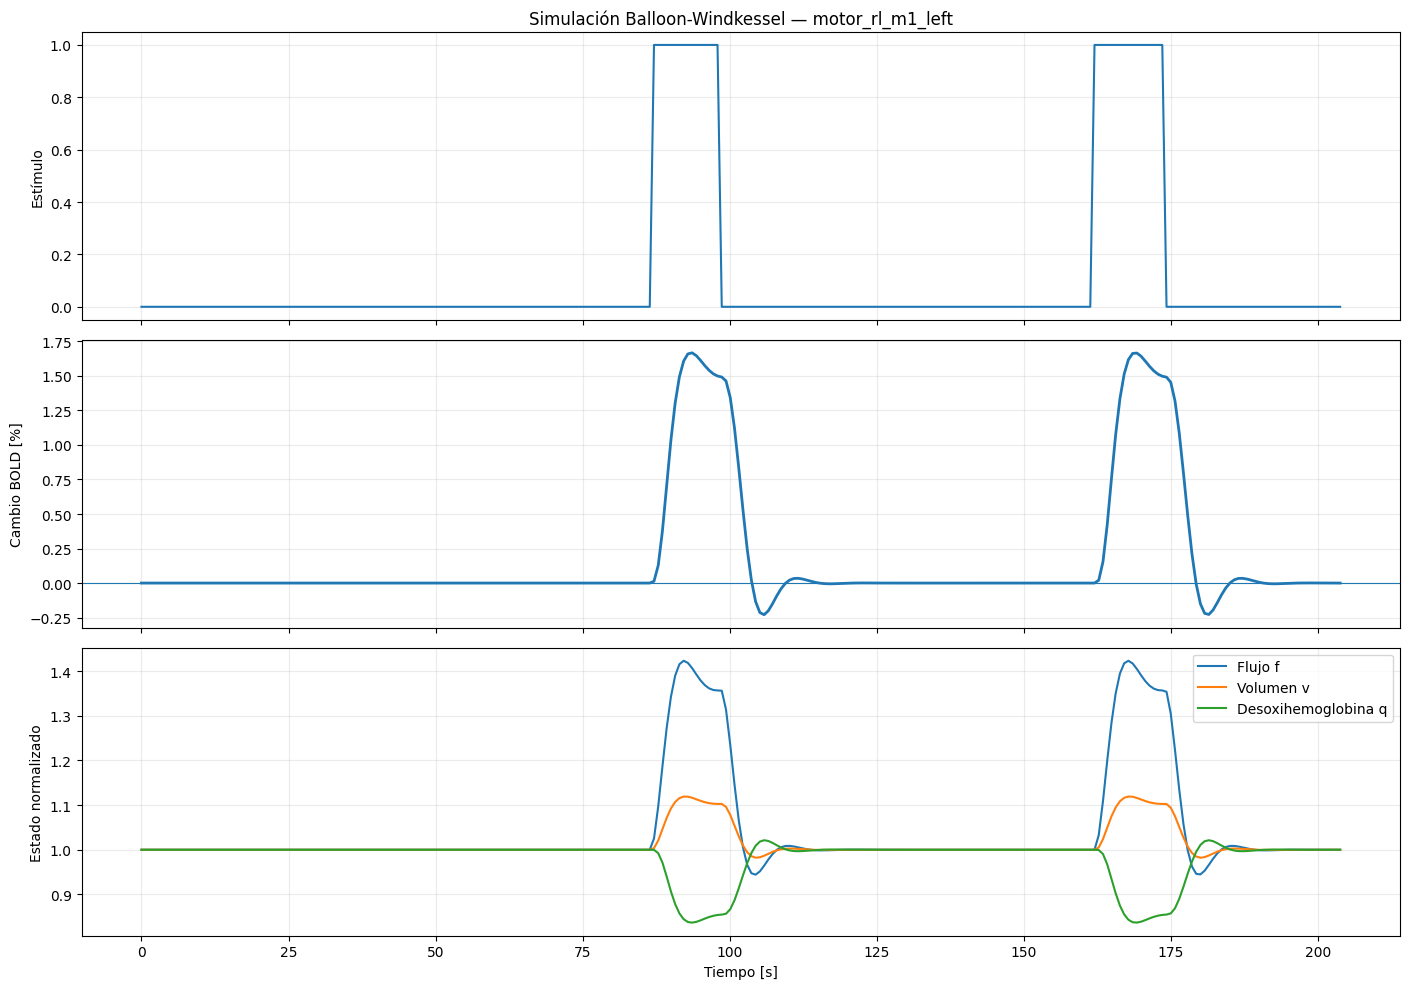

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_clean_motor_rl_m1_left.png


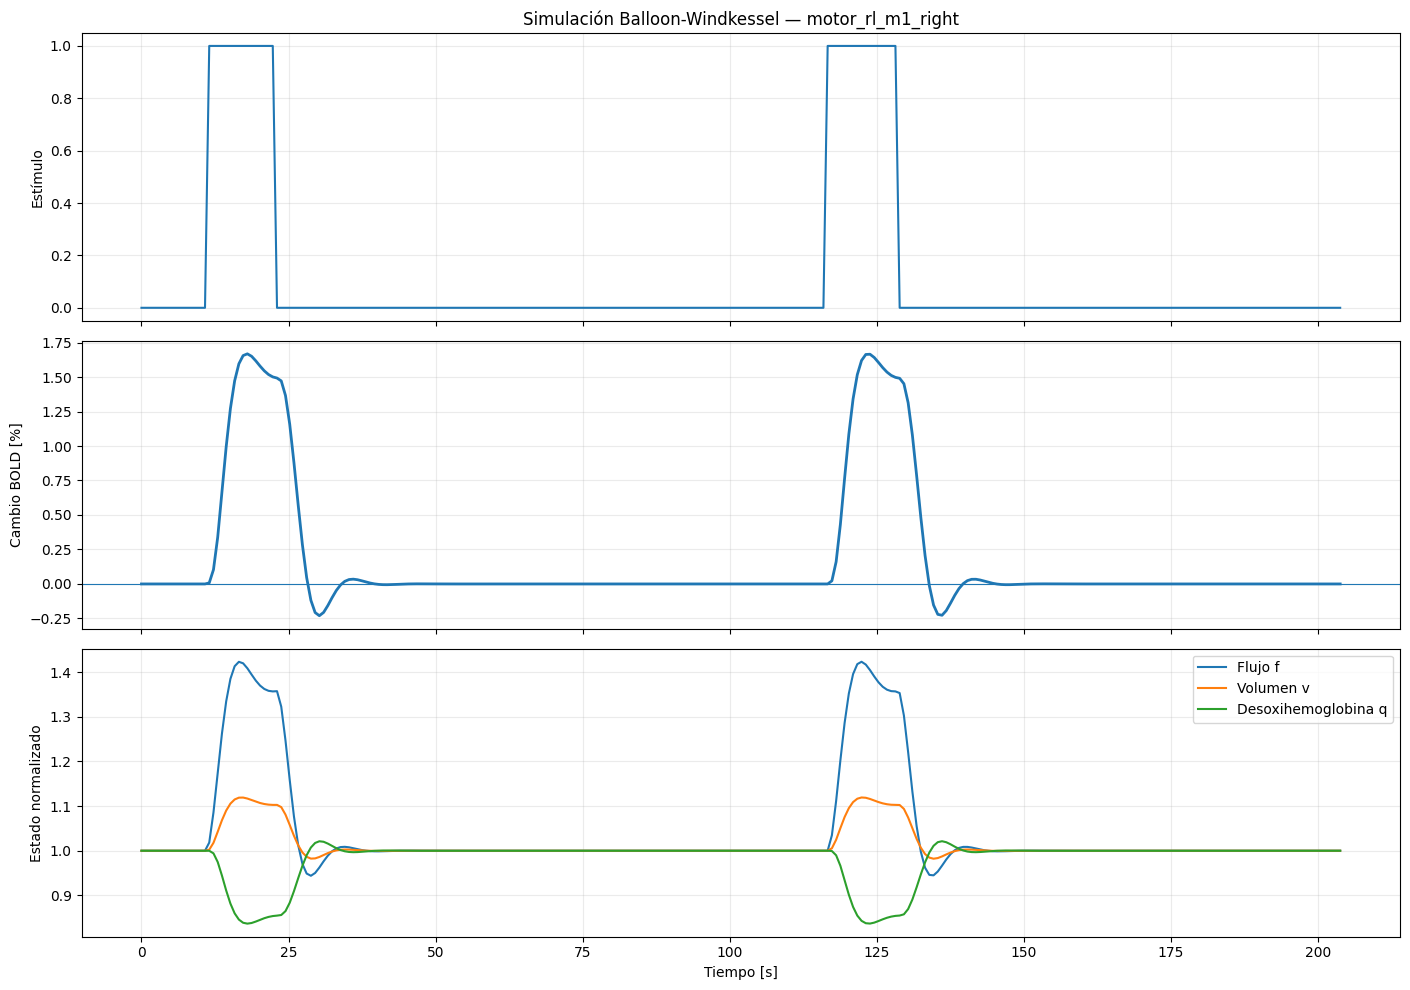

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_clean_motor_rl_m1_right.png


In [18]:
for scenario_name, result in clean_results.items():
    graficar_simulacion_limpia(
        result,
        scenario_name,
    )

In [19]:
HRF_DURATION_S = 32.0
HRF_DT_S = 0.05
HRF_STIMULUS_ONSET_S = 1.0
HRF_STIMULUS_DURATION_S = 1.0

hrf_times = np.arange(
    0.0,
    HRF_DURATION_S + HRF_DT_S,
    HRF_DT_S,
)

hrf_event = pd.DataFrame(
    {
        "onset_s": [
            HRF_STIMULUS_ONSET_S
        ],
        "duration_s": [
            HRF_STIMULUS_DURATION_S
        ],
        "amplitude": [
            1.0
        ],
        "condition": [
            "unit_stimulus"
        ],
        "end_s": [
            HRF_STIMULUS_ONSET_S
            + HRF_STIMULUS_DURATION_S
        ],
    }
)

ground_truth_hrf = simular_balloon_windkessel(
    frame_times=hrf_times,
    events=hrf_event,
    parameters=GROUND_TRUTH_PARAMETERS,
    max_step_s=0.02,
)

ground_truth_hrf["time_from_onset_s"] = (
    ground_truth_hrf["time_s"]
    - HRF_STIMULUS_ONSET_S
)

In [20]:
post_stimulus = ground_truth_hrf[
    ground_truth_hrf["time_s"]
    >= HRF_STIMULUS_ONSET_S
].copy()

peak_index = (
    post_stimulus["bold_fraction"]
    .idxmax()
)

peak_time_s = float(
    ground_truth_hrf.loc[
        peak_index,
        "time_s",
    ]
)

peak_amplitude_percent = float(
    ground_truth_hrf.loc[
        peak_index,
        "bold_percent",
    ]
)

after_peak = ground_truth_hrf[
    ground_truth_hrf["time_s"]
    >= peak_time_s
]

undershoot_index = (
    after_peak["bold_fraction"]
    .idxmin()
)

undershoot_time_s = float(
    ground_truth_hrf.loc[
        undershoot_index,
        "time_s",
    ]
)

undershoot_amplitude_percent = float(
    ground_truth_hrf.loc[
        undershoot_index,
        "bold_percent",
    ]
)

hrf_metrics = {
    "stimulus_onset_s": HRF_STIMULUS_ONSET_S,
    "stimulus_duration_s": HRF_STIMULUS_DURATION_S,
    "peak_amplitude_percent": peak_amplitude_percent,
    "time_to_peak_s": (
        peak_time_s
        - HRF_STIMULUS_ONSET_S
    ),
    "undershoot_amplitude_percent": (
        undershoot_amplitude_percent
    ),
    "time_to_undershoot_s": (
        undershoot_time_s
        - HRF_STIMULUS_ONSET_S
    ),
}

display(
    pd.DataFrame(
        [hrf_metrics]
    )
)

,stimulus_onset_s,stimulus_duration_s,peak_amplitude_percent,time_to_peak_s,undershoot_amplitude_percent,time_to_undershoot_s
0,1.0,1.0,0.514798,3.55,-0.078758,9.6


In [21]:
hrf_path = (
    SYNTHETIC_DATA_DIR
    / "ground_truth_hrf.csv"
)

ground_truth_hrf.to_csv(
    hrf_path,
    index=False,
)

hrf_metrics_path = (
    SYNTHETIC_RESULTS_DIR
    / "ground_truth_hrf_metrics.json"
)

with open(
    hrf_metrics_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        hrf_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("HRF guardada en:")
print(hrf_path)

HRF guardada en:
/content/drive/MyDrive/Proyecto_PINN_HRF/data/synthetic/ground_truth_hrf.csv


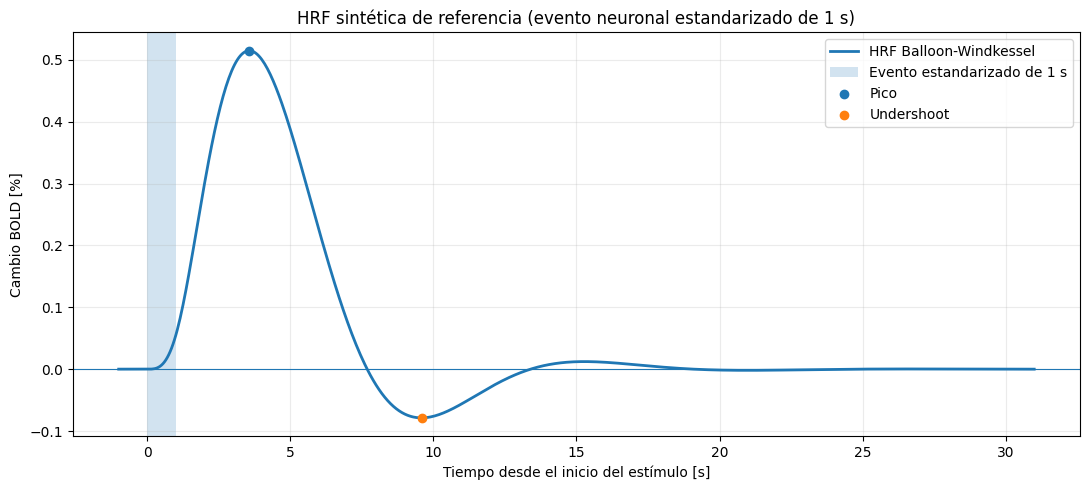

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_ground_truth_hrf.png


In [23]:
plt.figure(figsize=(11, 5))

plt.plot(
    ground_truth_hrf["time_from_onset_s"],
    ground_truth_hrf["bold_percent"],
    linewidth=2.0,
    label="HRF Balloon-Windkessel",
)

plt.axvspan(
    0.0,
    HRF_STIMULUS_DURATION_S,
    alpha=0.20,
    label="Evento estandarizado de 1 s",
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.scatter(
    hrf_metrics["time_to_peak_s"],
    hrf_metrics["peak_amplitude_percent"],
    label="Pico",
    zorder=3,
)

plt.scatter(
    hrf_metrics["time_to_undershoot_s"],
    hrf_metrics["undershoot_amplitude_percent"],
    label="Undershoot",
    zorder=3,
)

plt.xlabel("Tiempo desde el inicio del estímulo [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "HRF sintética de referencia "
    "(evento neuronal estandarizado de 1 s)"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

hrf_figure_path = (
    FIGURES_DIR
    / "synthetic_ground_truth_hrf.png"
)

plt.savefig(
    hrf_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada:", hrf_figure_path)

In [24]:
NOISY_DATA_DIR = (
    SYNTHETIC_DATA_DIR
    / "noisy"
)

NOISY_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SNR_LEVELS = {
    "snr_10": 10.0,
    "snr_5": 5.0,
    "snr_2": 2.0,
}

N_REPLICATES = 5
BASE_RANDOM_SEED = 20260717

NOISE_PARAMETERS = {
    "ar1_rho": 0.40,
    "white_power_fraction": 0.50,
    "ar1_power_fraction": 0.35,
    "drift_power_fraction": 0.15,
    "drift_period_1_s": 80.0,
    "drift_period_2_s": 140.0,
}

power_sum = (
    NOISE_PARAMETERS["white_power_fraction"]
    + NOISE_PARAMETERS["ar1_power_fraction"]
    + NOISE_PARAMETERS["drift_power_fraction"]
)

if not np.isclose(power_sum, 1.0):
    raise ValueError(
        "Las fracciones de potencia del ruido deben sumar 1."
    )

noise_config = {
    "snr_definition": (
        "std(clean_signal) / std(noise)"
    ),
    "snr_levels": SNR_LEVELS,
    "n_replicates": N_REPLICATES,
    "base_random_seed": BASE_RANDOM_SEED,
    **NOISE_PARAMETERS,
}

noise_config_path = (
    CONFIG_DIR
    / "synthetic_noise_config.json"
)

with open(
    noise_config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        noise_config,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Configuración guardada:")
print(noise_config_path)

Configuración guardada:
/content/drive/MyDrive/Proyecto_PINN_HRF/configs/synthetic_noise_config.json


In [25]:
def estandarizar_vector(
    values: np.ndarray,
) -> np.ndarray:
    """
    Centra un vector y lo escala a desviación estándar 1.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    centered = values - np.mean(values)
    standard_deviation = np.std(
        centered,
        ddof=0,
    )

    if standard_deviation < 1e-12:
        raise ValueError(
            "No se puede estandarizar un vector constante."
        )

    return centered / standard_deviation

In [26]:
def generar_ruido_ar1(
    n_points: int,
    rho: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Genera ruido AR(1) aproximadamente estacionario.
    """
    if not 0.0 <= rho < 1.0:
        raise ValueError(
            "rho debe encontrarse en [0, 1)."
        )

    innovations = rng.normal(
        loc=0.0,
        scale=1.0,
        size=n_points,
    )

    ar1 = np.empty(
        n_points,
        dtype=float,
    )

    ar1[0] = innovations[0]

    innovation_scale = np.sqrt(
        1.0 - rho**2
    )

    for index in range(1, n_points):
        ar1[index] = (
            rho * ar1[index - 1]
            + innovation_scale
            * innovations[index]
        )

    return estandarizar_vector(ar1)

In [27]:
def generar_deriva_lenta(
    time_s: np.ndarray,
    rng: np.random.Generator,
    period_1_s: float,
    period_2_s: float,
) -> np.ndarray:
    """
    Genera una combinación de oscilaciones lentas
    con fases aleatorias.
    """
    time_s = np.asarray(
        time_s,
        dtype=float,
    )

    phase_1 = rng.uniform(
        0.0,
        2.0 * np.pi,
    )

    phase_2 = rng.uniform(
        0.0,
        2.0 * np.pi,
    )

    drift = (
        np.sin(
            2.0
            * np.pi
            * time_s
            / period_1_s
            + phase_1
        )
        + 0.60
        * np.sin(
            2.0
            * np.pi
            * time_s
            / period_2_s
            + phase_2
        )
    )

    return estandarizar_vector(drift)

In [28]:
def agregar_ruido_estructurado(
    clean_signal: np.ndarray,
    time_s: np.ndarray,
    target_snr: float,
    random_seed: int,
    parameters: dict,
) -> dict:
    """
    Agrega ruido blanco, AR(1) y deriva lenta.

    El ruido total se escala para satisfacer:

        SNR = std(señal limpia) / std(ruido)
    """
    if target_snr <= 0:
        raise ValueError(
            "target_snr debe ser positivo."
        )

    clean_signal = np.asarray(
        clean_signal,
        dtype=float,
    )

    time_s = np.asarray(
        time_s,
        dtype=float,
    )

    if clean_signal.shape != time_s.shape:
        raise ValueError(
            "La señal y el tiempo deben tener "
            "la misma dimensión."
        )

    rng = np.random.default_rng(
        random_seed
    )

    n_points = len(clean_signal)

    white = estandarizar_vector(
        rng.normal(
            loc=0.0,
            scale=1.0,
            size=n_points,
        )
    )

    ar1 = generar_ruido_ar1(
        n_points=n_points,
        rho=parameters["ar1_rho"],
        rng=rng,
    )

    drift = generar_deriva_lenta(
        time_s=time_s,
        rng=rng,
        period_1_s=parameters[
            "drift_period_1_s"
        ],
        period_2_s=parameters[
            "drift_period_2_s"
        ],
    )

    white_component = (
        np.sqrt(
            parameters[
                "white_power_fraction"
            ]
        )
        * white
    )

    ar1_component = (
        np.sqrt(
            parameters[
                "ar1_power_fraction"
            ]
        )
        * ar1
    )

    drift_component = (
        np.sqrt(
            parameters[
                "drift_power_fraction"
            ]
        )
        * drift
    )

    combined_unscaled = (
        white_component
        + ar1_component
        + drift_component
    )

    clean_std = np.std(
        clean_signal,
        ddof=0,
    )

    combined_std = np.std(
        combined_unscaled,
        ddof=0,
    )

    if clean_std < 1e-12:
        raise ValueError(
            "La señal limpia tiene variabilidad nula."
        )

    target_noise_std = (
        clean_std
        / target_snr
    )

    scale_factor = (
        target_noise_std
        / combined_std
    )

    white_scaled = (
        scale_factor
        * white_component
    )

    ar1_scaled = (
        scale_factor
        * ar1_component
    )

    drift_scaled = (
        scale_factor
        * drift_component
    )

    total_noise = (
        white_scaled
        + ar1_scaled
        + drift_scaled
    )

    noisy_signal = (
        clean_signal
        + total_noise
    )

    realized_snr = (
        clean_std
        / np.std(
            total_noise,
            ddof=0,
        )
    )

    return {
        "noisy_signal": noisy_signal,
        "total_noise": total_noise,
        "white_noise": white_scaled,
        "ar1_noise": ar1_scaled,
        "drift_noise": drift_scaled,
        "target_snr": float(target_snr),
        "realized_snr": float(realized_snr),
        "clean_std": float(clean_std),
        "noise_std": float(
            np.std(
                total_noise,
                ddof=0,
            )
        ),
    }

In [29]:
def crear_mascara_evaluacion(
    frame_times: np.ndarray,
    events: pd.DataFrame,
    seconds_before_onset: float = 2.0,
    seconds_after_end: float = 20.0,
) -> dict:
    """
    Reserva una ventana alrededor del último bloque
    experimental para evaluación.
    """
    frame_times = np.asarray(
        frame_times,
        dtype=float,
    )

    sorted_events = (
        events
        .sort_values("onset_s")
        .reset_index(drop=True)
    )

    if len(sorted_events) < 2:
        raise ValueError(
            "Se requieren al menos dos bloques "
            "para crear la evaluación."
        )

    selected_event = (
        sorted_events.iloc[-1]
    )

    test_start_s = max(
        float(frame_times[0]),
        float(selected_event["onset_s"])
        - seconds_before_onset,
    )

    event_end_s = (
        float(selected_event["onset_s"])
        + float(
            selected_event["duration_s"]
        )
    )

    test_end_s = min(
        float(frame_times[-1]),
        event_end_s
        + seconds_after_end,
    )

    test_mask = (
        (frame_times >= test_start_s)
        & (frame_times <= test_end_s)
    )

    train_mask = ~test_mask

    if np.sum(test_mask) == 0:
        raise RuntimeError(
            "La máscara de prueba quedó vacía."
        )

    return {
        "train_mask": train_mask,
        "test_mask": test_mask,
        "test_start_s": test_start_s,
        "test_end_s": test_end_s,
        "held_out_onset_s": float(
            selected_event["onset_s"]
        ),
        "held_out_duration_s": float(
            selected_event["duration_s"]
        ),
    }

In [30]:
noise_summary_rows = []
generated_noisy_data = {}

scenario_names = list(
    clean_results.keys()
)

snr_items = list(
    SNR_LEVELS.items()
)

for scenario_index, scenario_name in enumerate(
    scenario_names
):
    clean_result = clean_results[
        scenario_name
    ]

    clean_signal = (
        clean_result["bold_fraction"]
        .to_numpy(dtype=float)
    )

    time_s = (
        clean_result["time_s"]
        .to_numpy(dtype=float)
    )

    scenario_events = scenarios[
        scenario_name
    ]["events"]

    mask_information = (
        crear_mascara_evaluacion(
            frame_times=time_s,
            events=scenario_events,
        )
    )

    for snr_index, (
        snr_name,
        target_snr,
    ) in enumerate(snr_items):

        output_directory = (
            NOISY_DATA_DIR
            / scenario_name
            / snr_name
        )

        output_directory.mkdir(
            parents=True,
            exist_ok=True,
        )

        for replicate in range(
            1,
            N_REPLICATES + 1,
        ):
            random_seed = (
                BASE_RANDOM_SEED
                + scenario_index * 10000
                + snr_index * 100
                + replicate
            )

            noise_result = (
                agregar_ruido_estructurado(
                    clean_signal=clean_signal,
                    time_s=time_s,
                    target_snr=target_snr,
                    random_seed=random_seed,
                    parameters=NOISE_PARAMETERS,
                )
            )

            noisy_table = (
                clean_result.copy()
            )

            noisy_table[
                "bold_clean_fraction"
            ] = clean_signal

            noisy_table[
                "bold_noisy_fraction"
            ] = noise_result[
                "noisy_signal"
            ]

            noisy_table[
                "noise_fraction"
            ] = noise_result[
                "total_noise"
            ]

            noisy_table[
                "noise_white_fraction"
            ] = noise_result[
                "white_noise"
            ]

            noisy_table[
                "noise_ar1_fraction"
            ] = noise_result[
                "ar1_noise"
            ]

            noisy_table[
                "noise_drift_fraction"
            ] = noise_result[
                "drift_noise"
            ]

            noisy_table[
                "bold_clean_percent"
            ] = (
                100.0
                * noisy_table[
                    "bold_clean_fraction"
                ]
            )

            noisy_table[
                "bold_noisy_percent"
            ] = (
                100.0
                * noisy_table[
                    "bold_noisy_fraction"
                ]
            )

            noisy_table["train_mask"] = (
                mask_information[
                    "train_mask"
                ].astype(int)
            )

            noisy_table["test_mask"] = (
                mask_information[
                    "test_mask"
                ].astype(int)
            )

            file_name = (
                f"{scenario_name}_"
                f"{snr_name}_"
                f"rep_{replicate:02d}.csv"
            )

            output_path = (
                output_directory
                / file_name
            )

            noisy_table.to_csv(
                output_path,
                index=False,
            )

            generated_noisy_data[
                (
                    scenario_name,
                    snr_name,
                    replicate,
                )
            ] = noisy_table

            noise_summary_rows.append(
                {
                    "scenario": scenario_name,
                    "run": scenarios[
                        scenario_name
                    ]["run"],
                    "roi": scenarios[
                        scenario_name
                    ]["roi"],
                    "condition": scenarios[
                        scenario_name
                    ]["condition"],
                    "snr_name": snr_name,
                    "target_snr": float(
                        target_snr
                    ),
                    "realized_snr": (
                        noise_result[
                            "realized_snr"
                        ]
                    ),
                    "replicate": replicate,
                    "random_seed": random_seed,
                    "clean_std_fraction": (
                        noise_result[
                            "clean_std"
                        ]
                    ),
                    "noise_std_fraction": (
                        noise_result[
                            "noise_std"
                        ]
                    ),
                    "n_train_points": int(
                        np.sum(
                            mask_information[
                                "train_mask"
                            ]
                        )
                    ),
                    "n_test_points": int(
                        np.sum(
                            mask_information[
                                "test_mask"
                            ]
                        )
                    ),
                    "test_start_s": (
                        mask_information[
                            "test_start_s"
                        ]
                    ),
                    "test_end_s": (
                        mask_information[
                            "test_end_s"
                        ]
                    ),
                    "held_out_onset_s": (
                        mask_information[
                            "held_out_onset_s"
                        ]
                    ),
                    "output_file": str(
                        output_path
                    ),
                }
            )

In [34]:
noise_summary = pd.DataFrame(
    noise_summary_rows
)

noise_summary_path = (
    SYNTHETIC_RESULTS_DIR
    / "noise_dataset_summary.csv"
)

noise_summary.to_csv(
    noise_summary_path,
    index=False,
)

print(
    "Cantidad total de señales ruidosas:",
    len(noise_summary),
)

print(
    "SNR realizado mínimo:",
    noise_summary[
        "realized_snr"
    ].min(),
)

print(
    "SNR realizado máximo:",
    noise_summary[
        "realized_snr"
    ].max(),
)

display(
    noise_summary.head(10)
)

Cantidad total de señales ruidosas: 60
SNR realizado mínimo: 1.9999999999999996
SNR realizado máximo: 10.000000000000002


,scenario,run,roi,condition,snr_name,target_snr,realized_snr,replicate,random_seed,clean_std_fraction,noise_std_fraction,n_train_points,n_test_points,test_start_s,test_end_s,held_out_onset_s,output_file
0,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,1,20260718,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
1,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,2,20260719,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
2,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,3,20260720,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
3,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,4,20260721,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
4,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_10,10.0,10.0,5,20260722,0.00479,0.000479,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
5,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_5,5.0,5.0,1,20260818,0.00479,0.000958,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
6,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_5,5.0,5.0,2,20260819,0.00479,0.000958,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
7,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_5,5.0,5.0,3,20260820,0.00479,0.000958,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
8,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_5,5.0,5.0,4,20260821,0.00479,0.000958,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...
9,motor_lr_m1_left,MOTOR_LR,M1_left,rh,snr_5,5.0,5.0,5,20260822,0.00479,0.000958,237,47,129.892,163.892,131.892,/content/drive/MyDrive/Proyecto_PINN_HRF/data/...


In [32]:
noise_summary[
    "absolute_snr_error"
] = np.abs(
    noise_summary["target_snr"]
    - noise_summary["realized_snr"]
)

display(
    noise_summary.groupby(
        "snr_name"
    )[
        [
            "target_snr",
            "realized_snr",
            "absolute_snr_error",
        ]
    ].agg(
        ["mean", "std", "min", "max"]
    )
)

if (
    noise_summary[
        "absolute_snr_error"
    ].max()
    > 1e-8
):
    raise RuntimeError(
        "El SNR realizado no coincide "
        "con el solicitado."
    )

print(
    "Todos los niveles de SNR fueron "
    "generados correctamente."
)

target_snr                  realized_snr                            \
               mean  std   min   max         mean           std   min   max   
snr_name                                                                      
snr_10         10.0  0.0  10.0  10.0         10.0  1.578334e-15  10.0  10.0   
snr_2           2.0  0.0   2.0   2.0          2.0  2.037621e-16   2.0   2.0   
snr_5           5.0  0.0   5.0   5.0          5.0  8.150484e-16   5.0   5.0   

         absolute_snr_error                                   
                       mean           std  min           max  
snr_name                                                      
snr_10         1.154632e-15  1.042975e-15  0.0  3.552714e-15  
snr_2          8.881784e-17  1.822504e-16  0.0  4.440892e-16  
snr_5          6.217249e-16  5.073635e-16  0.0  1.776357e-15

Todos los niveles de SNR fueron generados correctamente.


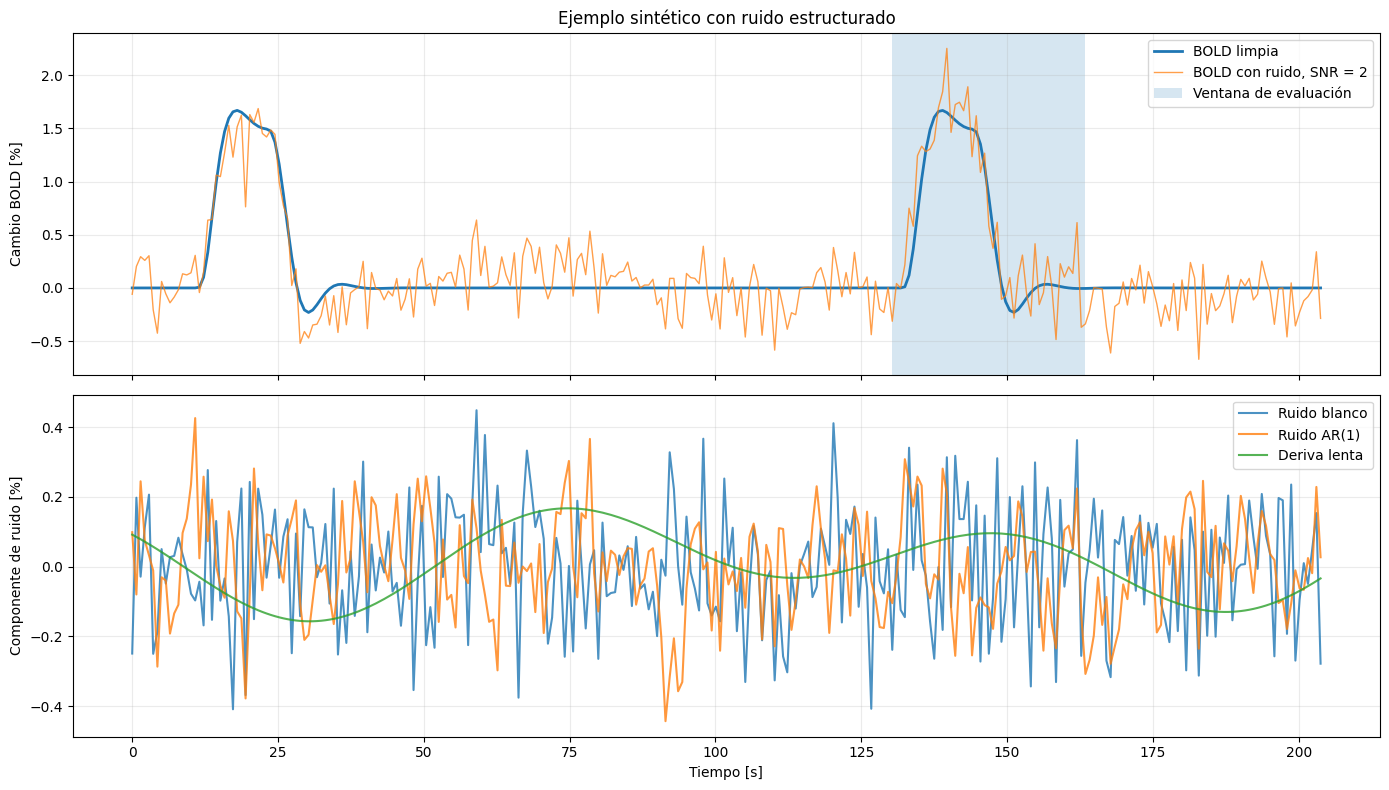

Figura guardada:
/content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/synthetic_noise_example_snr2.png


In [33]:
example_key = (
    "motor_lr_m1_left",
    "snr_2",
    1,
)

example = generated_noisy_data[
    example_key
]

test_points = (
    example["test_mask"]
    .to_numpy(dtype=bool)
)

test_time = (
    example.loc[
        test_points,
        "time_s",
    ]
)

figure, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
)

axes[0].plot(
    example["time_s"],
    example["bold_clean_percent"],
    linewidth=2.0,
    label="BOLD limpia",
)

axes[0].plot(
    example["time_s"],
    example["bold_noisy_percent"],
    linewidth=1.0,
    alpha=0.75,
    label="BOLD con ruido, SNR = 2",
)

axes[0].axvspan(
    float(test_time.min()),
    float(test_time.max()),
    alpha=0.18,
    label="Ventana de evaluación",
)

axes[0].set_ylabel(
    "Cambio BOLD [%]"
)

axes[0].set_title(
    "Ejemplo sintético con ruido estructurado"
)

axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    example["time_s"],
    100.0
    * example[
        "noise_white_fraction"
    ],
    label="Ruido blanco",
    alpha=0.8,
)

axes[1].plot(
    example["time_s"],
    100.0
    * example[
        "noise_ar1_fraction"
    ],
    label="Ruido AR(1)",
    alpha=0.8,
)

axes[1].plot(
    example["time_s"],
    100.0
    * example[
        "noise_drift_fraction"
    ],
    label="Deriva lenta",
    alpha=0.8,
)

axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel(
    "Componente de ruido [%]"
)
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()

noise_figure_path = (
    FIGURES_DIR
    / "synthetic_noise_example_snr2.png"
)

plt.savefig(
    noise_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada:")
print(noise_figure_path)